# 🏏 Bangla Sports Sentiment Analysis
## Model: Random Forest (RF) | TF-IDF + Chi2 Feature Selection
## 3 Data Splits: 70:30 | 80:20 | 90:10 | Hyperparameter Tuning
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('results_rf', exist_ok=True)

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    learning_curve, cross_val_score, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

print('✅ সব Library import সফল!')
print('Random Forest — Bangla Sports Sentiment Analysis')

✅ সব Library import সফল!
Random Forest — Bangla Sports Sentiment Analysis


## 📂 Step 2: Dataset Load

In [3]:
df = pd.read_excel('/content/drive/MyDrive/Dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
print('📊 Raw Dataset Shape:', df.shape)
print('\n📋 Columns:', df.columns.tolist())
print('\n📊 Category Distribution:')
print(df['Category'].value_counts())
df.head()

📊 Raw Dataset Shape: (82611, 3)

📋 Columns: ['Comment ', 'Category', 'Cleaned_Text']

📊 Category Distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 🧹 Step 3: Data Cleaning & Preprocessing

In [4]:
print('=== Data Quality Check ===')
print(f'Total rows       : {len(df):,}')
print(f'Missing Comment  : {df["Comment "].isna().sum()}')
print(f'Duplicate Comment: {df["Comment "].duplicated().sum():,}')

=== Data Quality Check ===
Total rows       : 82,611
Missing Comment  : 5
Duplicate Comment: 34,663


In [5]:
def clean_bangla(text):
    """Bangla text cleaner"""
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs remove
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)  # Non-Bangla remove
    return re.sub(r'\s+', ' ', text).strip()

df['clean'] = df['Comment '].apply(clean_bangla)
df = df[df['clean'].str.len() > 3].reset_index(drop=True)

# Majority vote — conflicting labels resolve
df_clean = df.groupby('clean')['Category'].agg(
    lambda x: x.value_counts().idxmax()
).reset_index()
df_clean.columns = ['text', 'label']

print(f'Raw          : {len(df):,} rows')
print(f'After cleanup: {len(df_clean):,} rows')
print(f'\nFinal Category Distribution:')
print(df_clean['label'].value_counts())
print(f'Balance: {df_clean["label"].value_counts(normalize=True).mul(100).round(1).to_dict()}')

Raw          : 82,047 rows
After cleanup: 46,325 rows

Final Category Distribution:
label
Positive    25774
Negative    20551
Name: count, dtype: int64
Balance: {'Positive': 55.6, 'Negative': 44.4}


## 📊 Step 4: EDA

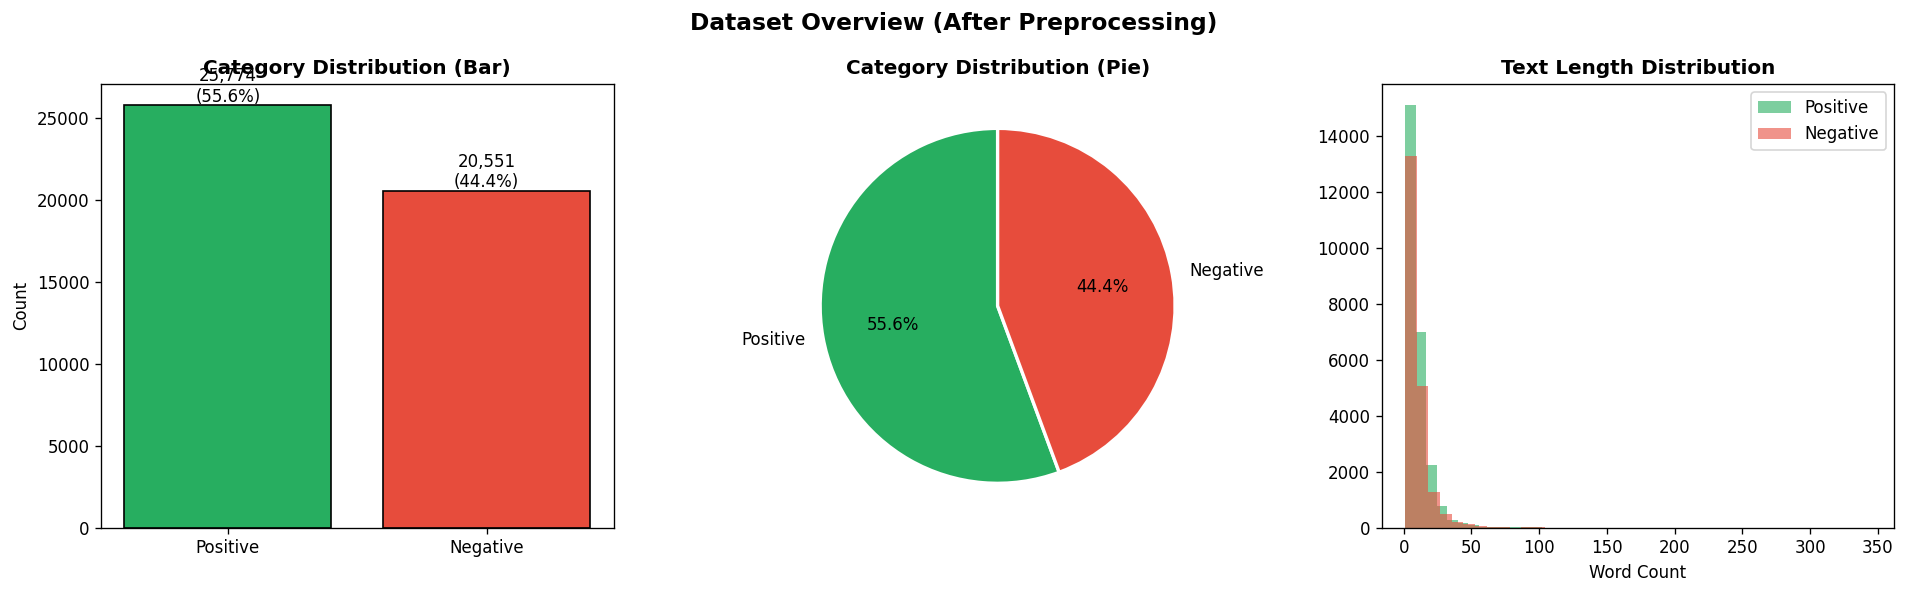

✅ Saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview (After Preprocessing)', fontsize=14, fontweight='bold')
cat_counts = df_clean['label'].value_counts()
colors_main = ['#27ae60', '#e74c3c']

bars = axes[0].bar(cat_counts.index, cat_counts.values, color=colors_main, edgecolor='black')
axes[0].set_title('Category Distribution (Bar)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200,
                 f'{v:,}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors_main, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Category Distribution (Pie)', fontweight='bold')

df_clean['text_len'] = df_clean['text'].apply(lambda x: len(x.split()))
axes[2].hist(df_clean[df_clean['label']=='Positive']['text_len'],
             bins=40, alpha=0.6, color='#27ae60', label='Positive')
axes[2].hist(df_clean[df_clean['label']=='Negative']['text_len'],
             bins=40, alpha=0.6, color='#e74c3c', label='Negative')
axes[2].set_title('Text Length Distribution', fontweight='bold')
axes[2].set_xlabel('Word Count'); axes[2].legend()

plt.tight_layout()
plt.savefig('results_rf/01_dataset_overview.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

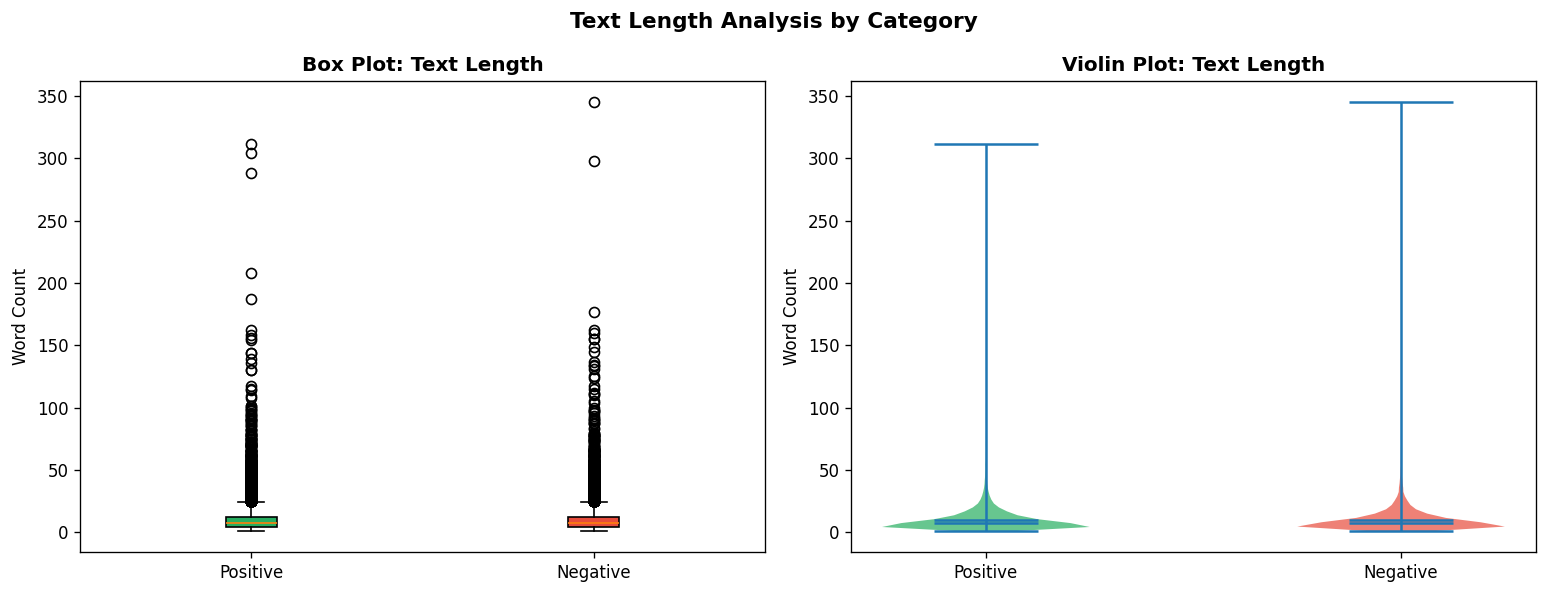

✅ Saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Text Length Analysis by Category', fontsize=13, fontweight='bold')

pos_len = df_clean[df_clean['label']=='Positive']['text_len'].values
neg_len = df_clean[df_clean['label']=='Negative']['text_len'].values

bp = axes[0].boxplot([pos_len, neg_len], labels=['Positive','Negative'], patch_artist=True)
bp['boxes'][0].set_facecolor('#27ae60'); bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Box Plot: Text Length', fontweight='bold')
axes[0].set_ylabel('Word Count')

vp = axes[1].violinplot([pos_len, neg_len], positions=[1,2], showmeans=True, showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['#27ae60','#e74c3c'][i]); pc.set_alpha(0.7)
axes[1].set_xticks([1,2]); axes[1].set_xticklabels(['Positive','Negative'])
axes[1].set_title('Violin Plot: Text Length', fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('results_rf/02_boxplot_violin.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🔤 Step 5: Feature Extraction + Selection
### Strategy: TF-IDF → Chi2 Feature Selection → Random Forest
RF sparse high-dim data তে ভালো কাজ করে না, তাই chi2 দিয়ে top features নির্বাচন করা হয়।

In [8]:
le = LabelEncoder()
y = le.fit_transform(df_clean['label'])  # Negative=0, Positive=1
X = df_clean['text'].values

print(f'✅ X size: {len(X):,}')
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Negative: {np.sum(y==0):,}  |  Positive: {np.sum(y==1):,}')

✅ X size: 46,325
Label encoding: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Negative: 20,551  |  Positive: 25,774


## 🔧 Step 6: Hyperparameter Tuning (80:20 Split)
RandomizedSearchCV use করা হচ্ছে — GridSearch এর চেয়ে দ্রুত।

In [24]:
print('🔧 80:20 split এ Hyperparameter Tuning শুরু...')
print('(এটা কিছু সময় নিতে পারে...)')

X_tr80, X_te80, y_tr80, y_te80 = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# TF-IDF + Chi2 Feature Selection Pipeline
tfidf_tune = TfidfVectorizer(
    ngram_range=(1,2), max_features=12000,
    sublinear_tf=True, min_df=2
)
Xtr_tfidf = tfidf_tune.fit_transform(X_tr80)
Xte_tfidf = tfidf_tune.transform(X_te80)

# Chi2 Feature Selection
selector_tune = SelectKBest(chi2, k=2000)
Xtr_sel = selector_tune.fit_transform(Xtr_tfidf, y_tr80)
Xte_sel = selector_tune.transform(Xte_tfidf)
print(f'Feature shape after selection: {Xtr_sel.shape}')

# RandomizedSearchCV for RF
param_dist = {
    'n_estimators'    : [100, 150, 200, 300],
    'max_depth'       : [None, 20, 30], # Reduced max_depth to fight overfitting
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [3, 5, 10], # Increased min_samples_leaf to fight overfitting
    'max_features'    : ['sqrt', 'log2', 0.3],
    'class_weight'    : [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=2)
random_search = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=20,          # 20 random combinations
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    random_state=42,
    verbose=1
)
random_search.fit(Xtr_sel, y_tr80)

best_params   = random_search.best_params_
best_cv_score = random_search.best_score_

print('\n' + '='*55)
print('✅ Tuning সম্পন্ন!')
print(f'Best CV Accuracy: {best_cv_score*100:.2f}%')
print('Best Parameters:')
for k,v in best_params.items(): print(f'  {k}: {v}')

🔧 80:20 split এ Hyperparameter Tuning শুরু...
(এটা কিছু সময় নিতে পারে...)
Feature shape after selection: (37060, 2000)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Tuning সম্পন্ন!
Best CV Accuracy: 64.68%
Best Parameters:
  n_estimators: 200
  min_samples_split: 10
  min_samples_leaf: 3
  max_features: sqrt
  max_depth: None
  class_weight: None


## 🚀 Step 7: তিনটা Split এ Training & Evaluation

In [25]:
splits      = [('70:30', 0.30), ('80:20', 0.20), ('90:10', 0.10)]
colors_roc  = ['#3498db', '#e74c3c', '#27ae60']
all_results = {}

print('🚀 Training শুরু — Best Params দিয়ে তিনটা Split...')
print('='*65)

for sname, tsize in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=tsize, random_state=42, stratify=y
    )

    # TF-IDF
    tfidf = TfidfVectorizer(
        ngram_range=(1,2), max_features=12000,
        sublinear_tf=True, min_df=2
    )
    Xtr_t = tfidf.fit_transform(X_train)
    Xte_t = tfidf.transform(X_test)

    # Chi2 Feature Selection
    selector = SelectKBest(chi2, k=2000)
    Xtr_f = selector.fit_transform(Xtr_t, y_train)
    Xte_f = selector.transform(Xte_t)

    # Random Forest with best params
    model_params = best_params.copy()
    # Remove 'class_weight' from tuned parameters if it exists, to explicitly set it
    if 'class_weight' in model_params:
        del model_params['class_weight']
    model = RandomForestClassifier(
        **model_params,
        class_weight='balanced', # Explicitly set class_weight
        random_state=42,
        n_jobs=2
    )
    model.fit(Xtr_f, y_train)

    y_pred = model.predict(Xte_f)
    y_prob = model.predict_proba(Xte_f)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    pc_c, rc_c, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rc_c, pc_c)

    # Feature importances
    feat_imp = model.feature_importances_

    all_results[sname] = dict(
        accuracy=acc, precision=prec, recall=rec, f1=f1,
        cm=cm, fpr=fpr, tpr=tpr, roc_auc=roc_auc,
        pc=pc_c, rc=rc_c, pr_auc=pr_auc,
        model=model, tfidf=tfidf, selector=selector,
        feat_imp=feat_imp,
        Xtr_f=Xtr_f, Xte_f=Xte_f,
        y_train=y_train, y_test=y_test,
        train_size=len(X_train), test_size_n=len(X_test)
    )

    print(f'\n📊 Split {sname}')
    print(f'   Train: {len(X_train):,} | Test: {len(X_test):,}')
    print(f'   Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'   Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')
    print(f'   ROC-AUC  : {roc_auc:.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['Negative','Positive'], digits=4))

split_names = list(all_results.keys())
print('\n✅ তিনটা Split সম্পন্ন!')

🚀 Training শুরু — Best Params দিয়ে তিনটা Split...

📊 Split 70:30
   Train: 32,427 | Test: 13,898
   Accuracy : 0.6320 (63.20%)
   Precision: 0.7147 | Recall: 0.5634 | F1: 0.6301
   ROC-AUC  : 0.6926
              precision    recall  f1-score   support

    Negative     0.5673    0.7180    0.6338      6166
    Positive     0.7147    0.5634    0.6301      7732

    accuracy                         0.6320     13898
   macro avg     0.6410    0.6407    0.6320     13898
weighted avg     0.6493    0.6320    0.6317     13898


📊 Split 80:20
   Train: 37,060 | Test: 9,265
   Accuracy : 0.6330 (63.30%)
   Precision: 0.7166 | Recall: 0.5631 | F1: 0.6307
   ROC-AUC  : 0.6935
              precision    recall  f1-score   support

    Negative     0.5681    0.7207    0.6353      4110
    Positive     0.7166    0.5631    0.6307      5155

    accuracy                         0.6330      9265
   macro avg     0.6423    0.6419    0.6330      9265
weighted avg     0.6507    0.6330    0.6327      9265

## 📈 Step 8: Confusion Matrix

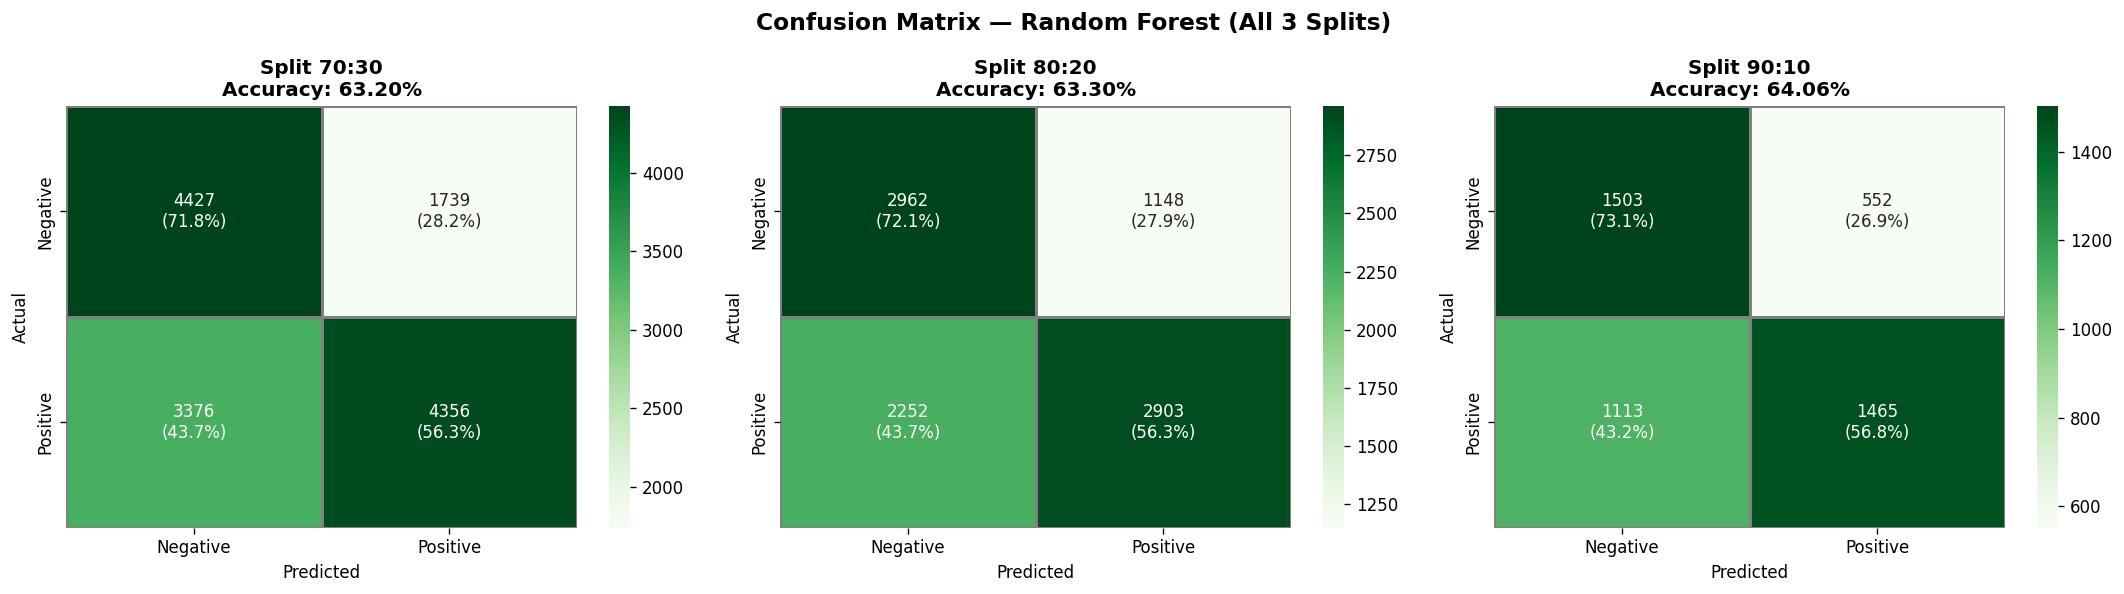

✅ Saved!


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — Random Forest (All 3 Splits)', fontsize=14, fontweight='bold')

for i, (sname, res) in enumerate(all_results.items()):
    cm = res['cm']
    cm_p = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis] * 100
    ann = np.array([[f'{cm[r,c]}\n({cm_p[r,c]:.1f}%)' for c in range(2)] for r in range(2)])
    sns.heatmap(cm, annot=ann, fmt='', ax=axes[i], cmap='Greens',
                linewidths=1.5, linecolor='gray',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    axes[i].set_title(f'Split {sname}\nAccuracy: {res["accuracy"]*100:.2f}%', fontweight='bold')
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results_rf/03_confusion_matrix.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📉 Step 9: ROC Curve

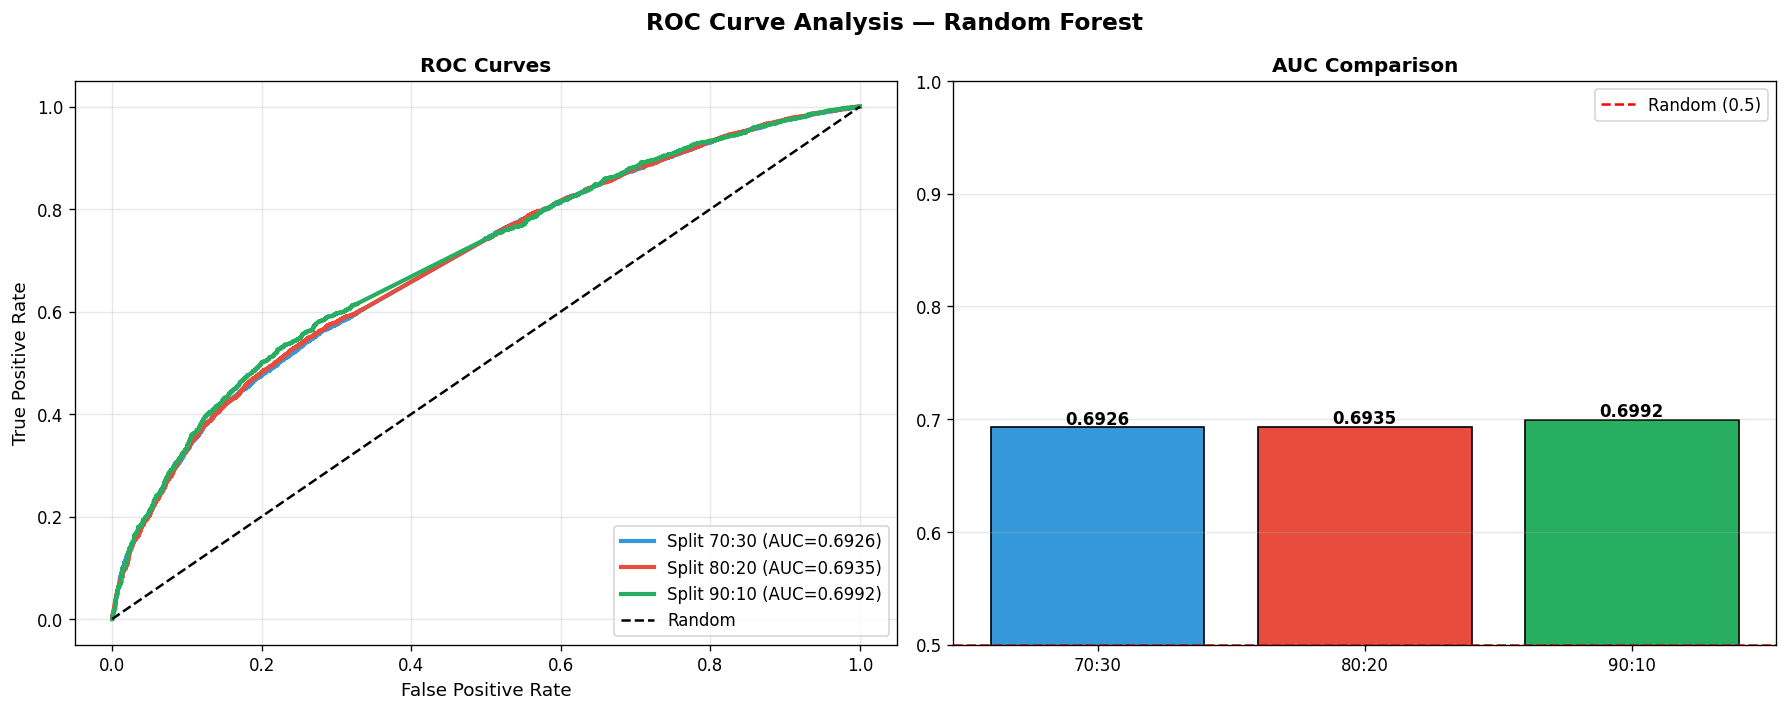

✅ Saved!


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve Analysis — Random Forest', fontsize=14, fontweight='bold')

for i, (sname, res) in enumerate(all_results.items()):
    axes[0].plot(res['fpr'], res['tpr'], color=colors_roc[i], lw=2.5,
                 label=f'Split {sname} (AUC={res["roc_auc"]:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

auc_v = [all_results[s]['roc_auc'] for s in split_names]
bars  = axes[1].bar(split_names, auc_v, color=colors_roc, edgecolor='black')
axes[1].set_ylim([0.5, 1.0])
axes[1].axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='Random (0.5)')
for bar, v in zip(bars, auc_v):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('AUC Comparison', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_rf/04_roc_curve.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📊 Step 10: Precision-Recall Curve

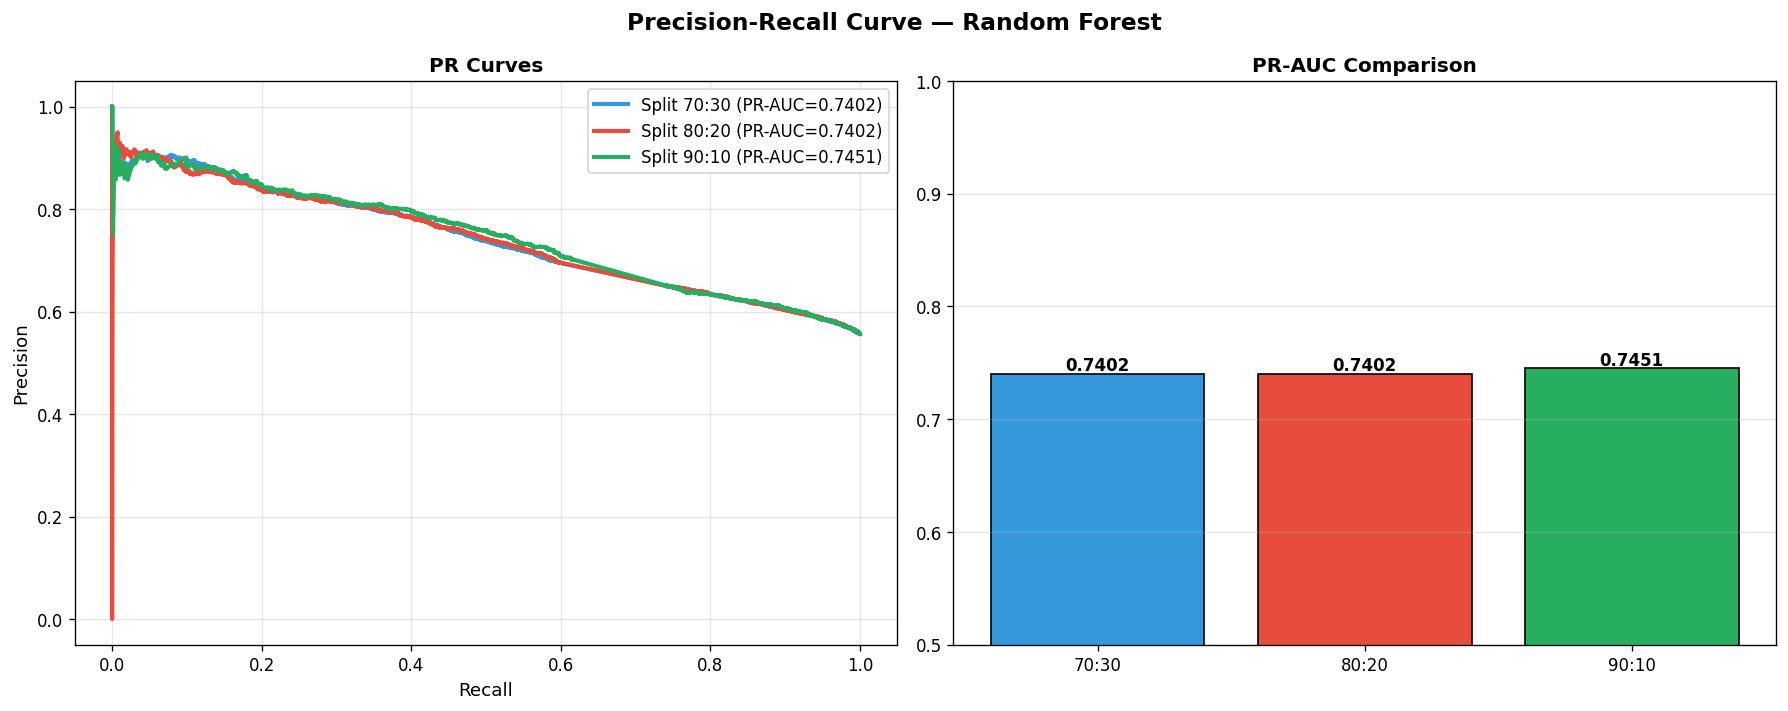

✅ Saved!


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Precision-Recall Curve — Random Forest', fontsize=14, fontweight='bold')

for i, (sname, res) in enumerate(all_results.items()):
    axes[0].plot(res['rc'], res['pc'], color=colors_roc[i], lw=2.5,
                 label=f'Split {sname} (PR-AUC={res["pr_auc"]:.4f})')
axes[0].set_xlabel('Recall', fontsize=11); axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('PR Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

pr_v  = [all_results[s]['pr_auc'] for s in split_names]
bars  = axes[1].bar(split_names, pr_v, color=colors_roc, edgecolor='black')
axes[1].set_ylim([0.5, 1.0])
for bar, v in zip(bars, pr_v):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('PR-AUC Comparison', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_rf/05_pr_curve.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📉 Step 11: Learning Curves

Learning Curves তৈরি হচ্ছে (সময় লাগবে)...


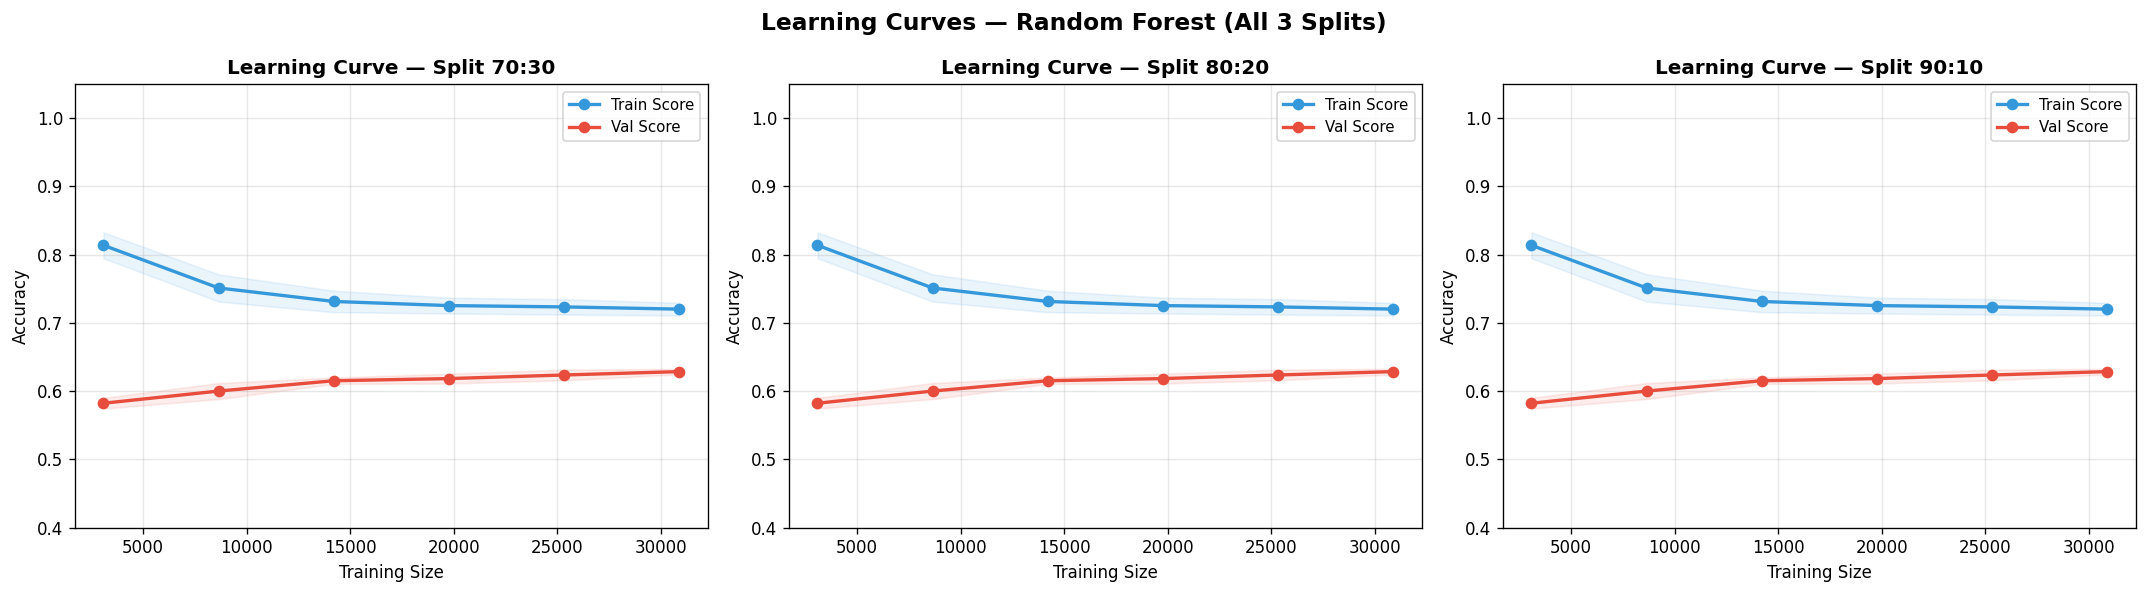

✅ Saved!


In [29]:
print('Learning Curves তৈরি হচ্ছে (সময় লাগবে)...')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves — Random Forest (All 3 Splits)', fontsize=14, fontweight='bold')

# Build combined pipeline for learning curve
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.base import BaseEstimator, TransformerMixin

class Chi2Selector(BaseEstimator, TransformerMixin):
    def __init__(self, k=2000):
        self.k = k
        self.sel = SelectKBest(chi2, k=k)
    def fit(self, X, y):
        self.sel.fit(X, y); return self
    def transform(self, X):
        return self.sel.transform(X)

lc_pipe = SKPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=12000,
                              sublinear_tf=True, min_df=2)),
    ('sel',   Chi2Selector(k=2000)),
    ('rf',    RandomForestClassifier(**best_params, random_state=42, n_jobs=2))
])

for i, (sname, _) in enumerate(all_results.items()):
    ts, trs, vs = learning_curve(
        lc_pipe, X, y,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=3, scoring='accuracy', n_jobs=1
    )
    trm = trs.mean(1); vm = vs.mean(1)
    axes[i].plot(ts, trm, 'o-', color='#3498db', label='Train Score', lw=2)
    axes[i].fill_between(ts, trm-trs.std(1), trm+trs.std(1), alpha=0.1, color='#3498db')
    axes[i].plot(ts, vm, 'o-', color='#e74c3c', label='Val Score', lw=2)
    axes[i].fill_between(ts, vm-vs.std(1), vm+vs.std(1), alpha=0.1, color='#e74c3c')
    axes[i].set_title(f'Learning Curve — Split {sname}', fontweight='bold')
    axes[i].set_xlabel('Training Size'); axes[i].set_ylabel('Accuracy')
    axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)
    axes[i].set_ylim([0.4, 1.05])

plt.tight_layout()
plt.savefig('results_rf/06_learning_curves.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 📊 Step 12: Metrics Comparison Bar Charts

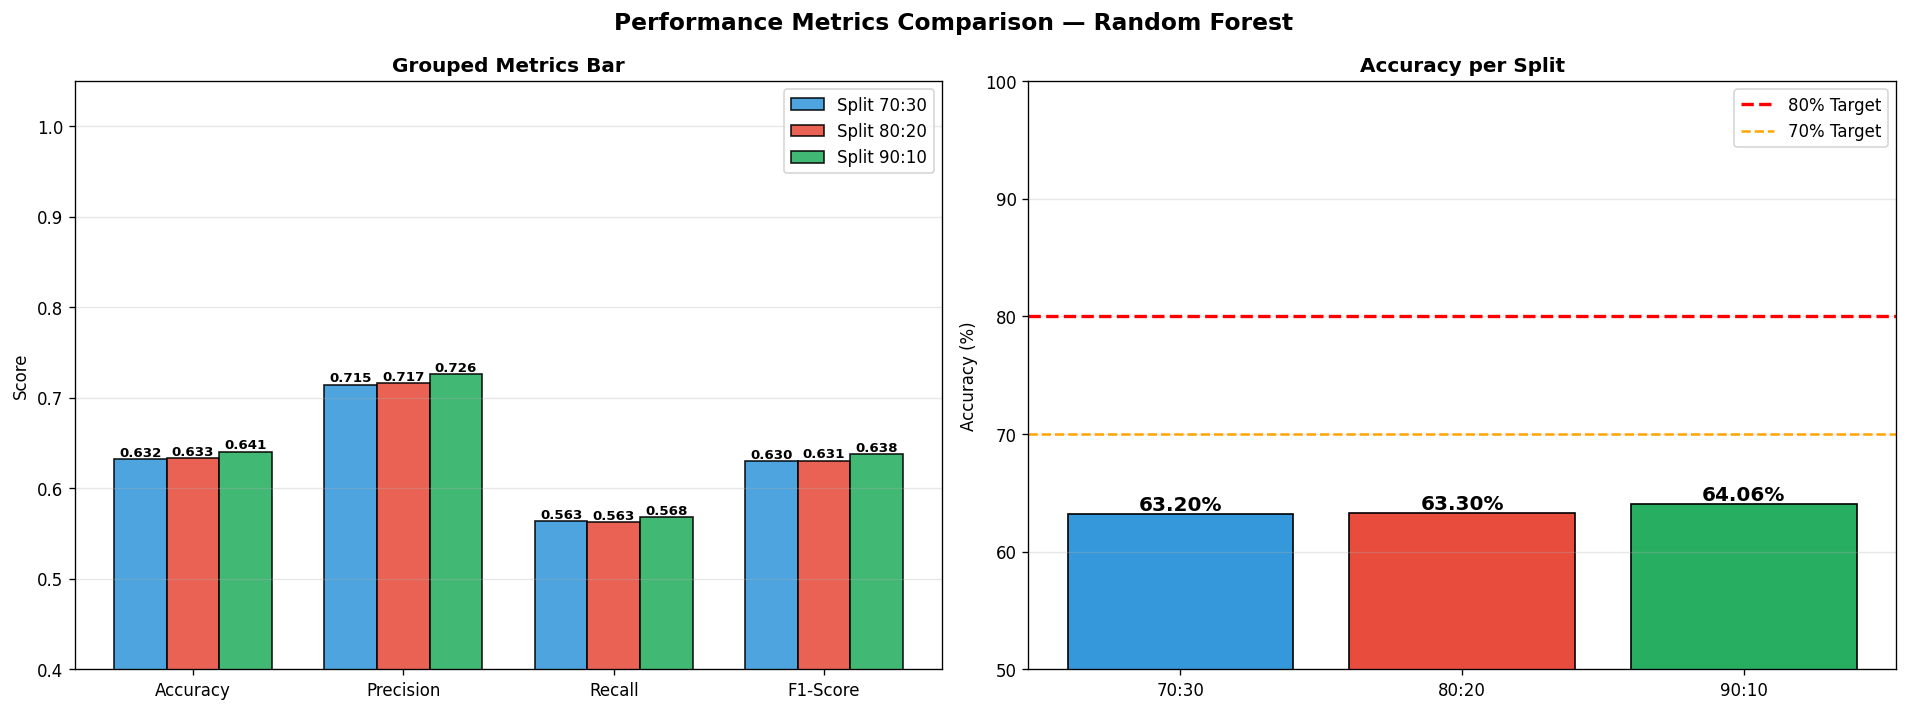

✅ Saved!


In [30]:
metrics = ['accuracy','precision','recall','f1']
mlbls   = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(metrics)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Metrics Comparison — Random Forest', fontsize=14, fontweight='bold')

for i, (sname, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    bars = axes[0].bar(x+i*w, vals, w, label=f'Split {sname}',
                       color=colors_roc[i], edgecolor='black', alpha=0.88)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, v+0.003,
                     f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x+w); axes[0].set_xticklabels(mlbls)
axes[0].set_ylim([0.4, 1.05]); axes[0].set_ylabel('Score')
axes[0].set_title('Grouped Metrics Bar', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

acc_p = [all_results[s]['accuracy']*100 for s in split_names]
bars2 = axes[1].bar(split_names, acc_p, color=colors_roc, edgecolor='black')
axes[1].axhline(y=80, color='red', linestyle='--', lw=2, label='80% Target')
axes[1].axhline(y=70, color='orange', linestyle='--', lw=1.5, label='70% Target')
for bar, v in zip(bars2, acc_p):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim([50, 100]); axes[1].set_title('Accuracy per Split', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_rf/07_metrics_comparison.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🔥 Step 13: Feature Importance (RF Top Features)

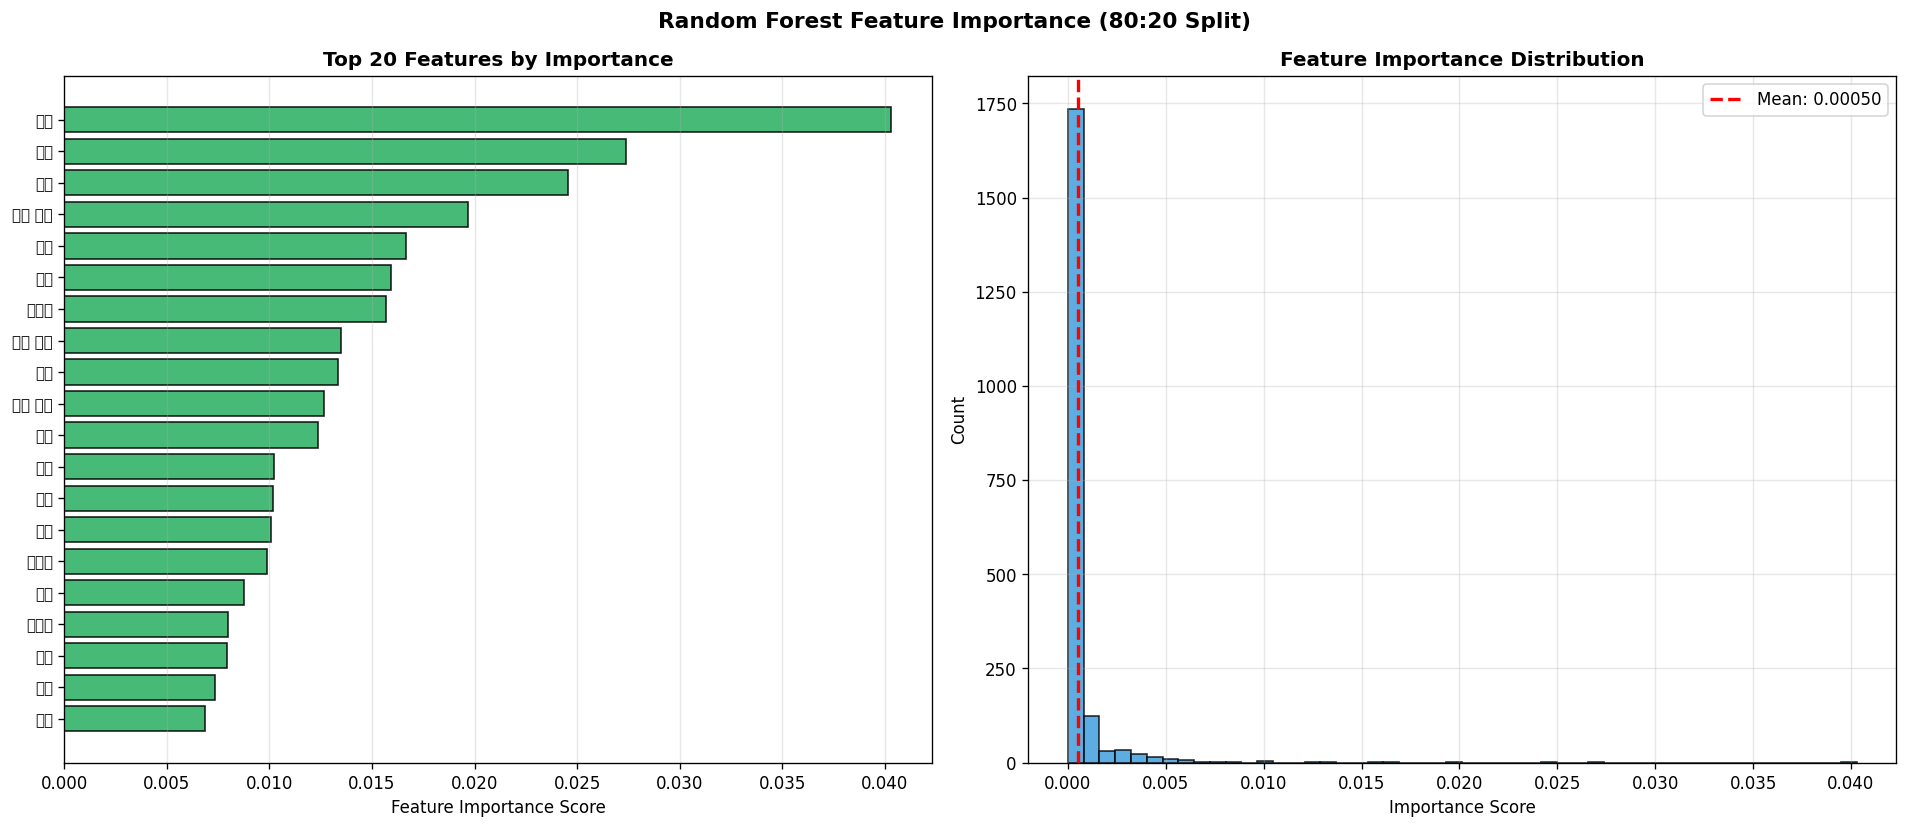

✅ Saved!


In [31]:
# Use 80:20 split model
model_80   = all_results['80:20']['model']
tfidf_80   = all_results['80:20']['tfidf']
sel_80     = all_results['80:20']['selector']

# Get selected feature names
all_feat_names = np.array(tfidf_80.get_feature_names_out())
sel_mask       = sel_80.get_support()
selected_names = all_feat_names[sel_mask]

importances = model_80.feature_importances_
top20_idx   = np.argsort(importances)[-20:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Random Forest Feature Importance (80:20 Split)', fontsize=13, fontweight='bold')

# Top 20 overall
axes[0].barh(range(20), importances[top20_idx][::-1],
             color='#27ae60', edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(selected_names[top20_idx][::-1], fontsize=9)
axes[0].set_title('Top 20 Features by Importance', fontweight='bold')
axes[0].set_xlabel('Feature Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# Distribution of all feature importances
axes[1].hist(importances, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].axvline(importances.mean(), color='red', linestyle='--', lw=2,
                label=f'Mean: {importances.mean():.5f}')
axes[1].set_title('Feature Importance Distribution', fontweight='bold')
axes[1].set_xlabel('Importance Score'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results_rf/08_feature_importance.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🗺️ Step 14: Correlation Heatmap

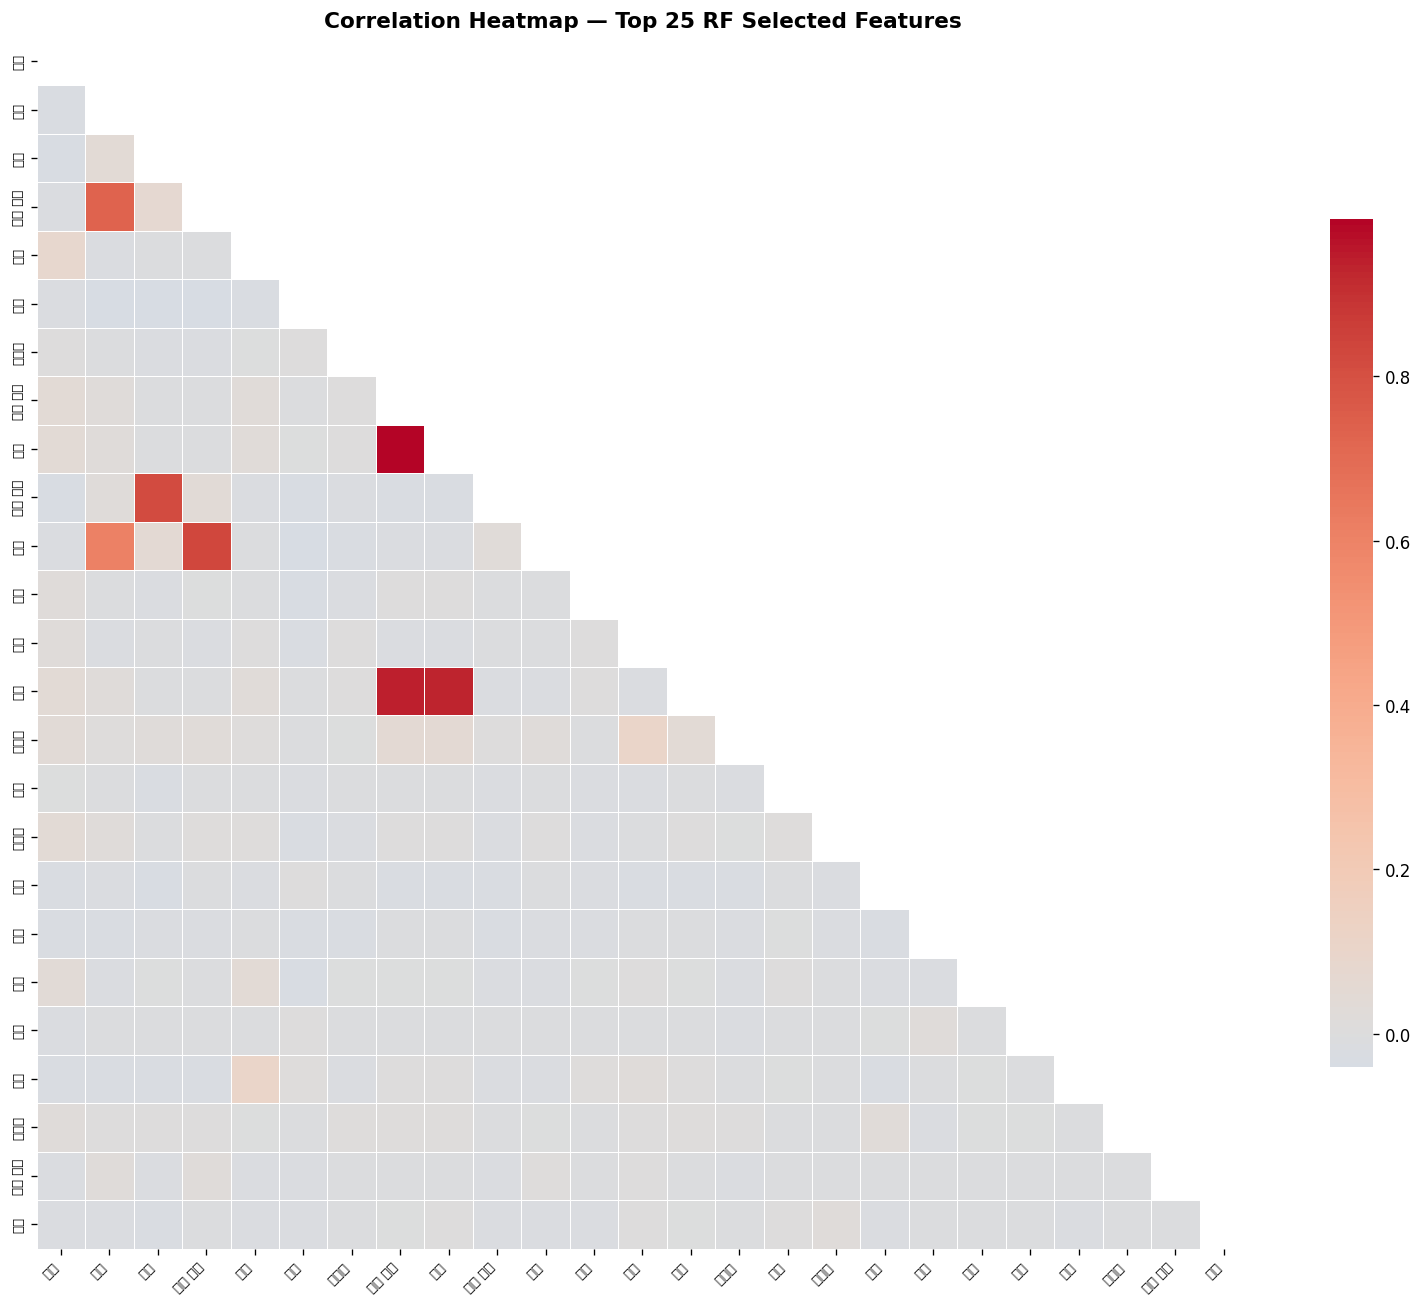

✅ Saved!


In [32]:
# Top 25 features by importance for correlation
top25_idx = np.argsort(importances)[-25:][::-1]
top25_names = selected_names[top25_idx]

Xs_sample = all_results['80:20']['Xtr_f'][:3000, top25_idx]
if hasattr(Xs_sample, 'toarray'):
    Xs_sample = Xs_sample.toarray()

X_top25_df  = pd.DataFrame(Xs_sample, columns=top25_names)
corr_matrix = X_top25_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Heatmap — Top 25 RF Selected Features', fontsize=13, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('results_rf/09_correlation_heatmap.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🗺️ Step 15: PCA Scatter Plot

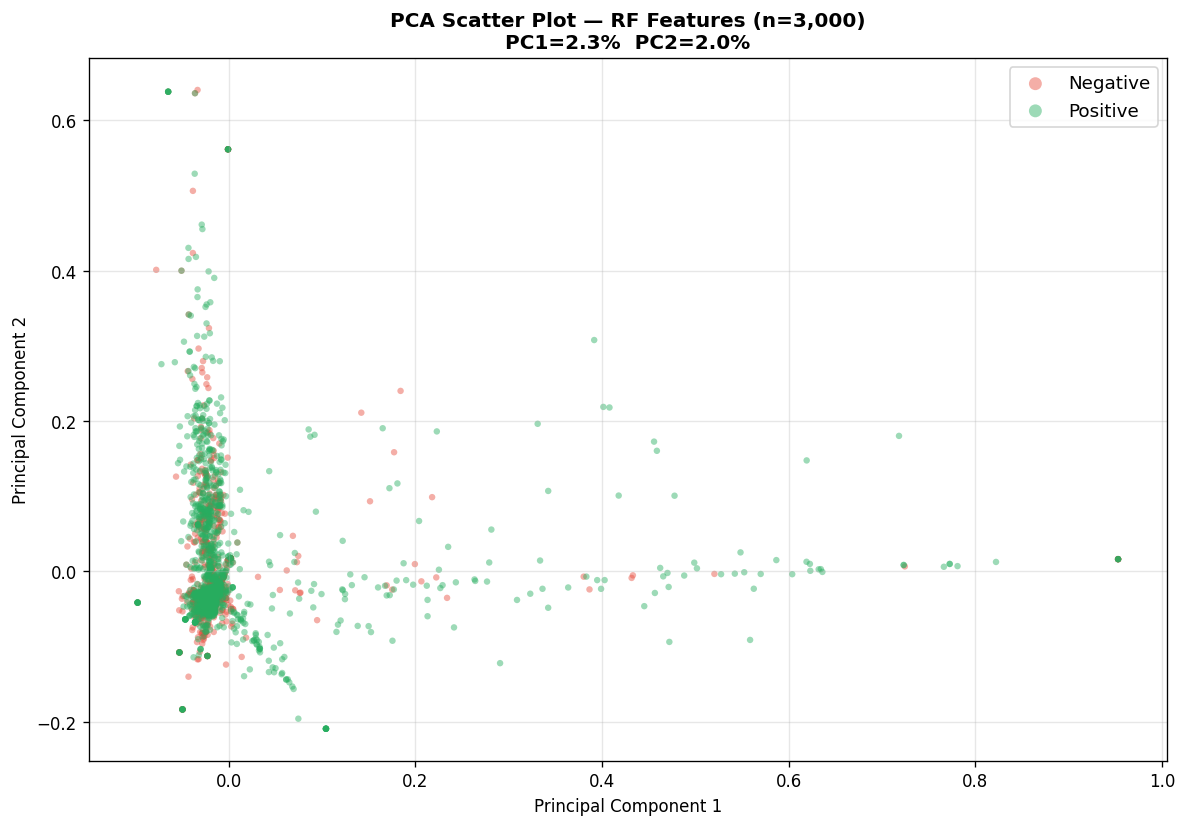

✅ Saved!


In [33]:
from sklearn.decomposition import PCA

Xtr_f_80 = all_results['80:20']['Xtr_f']
y_tr_80  = all_results['80:20']['y_train']

sidx = np.random.RandomState(42).choice(Xtr_f_80.shape[0], 3000, replace=False)
Xsp  = Xtr_f_80[sidx]
if hasattr(Xsp, 'toarray'): Xsp = Xsp.toarray()
ysp  = y_tr_80[sidx]

pca = PCA(n_components=2, random_state=42)
Xp  = pca.fit_transform(Xsp)

fig, ax = plt.subplots(figsize=(10, 7))
for ci, cls in enumerate(['Negative', 'Positive']):
    mask = ysp == ci
    ax.scatter(Xp[mask,0], Xp[mask,1],
               c=['#e74c3c','#27ae60'][ci], label=cls,
               alpha=0.45, s=15, edgecolors='none')
ax.set_title(
    f'PCA Scatter Plot — RF Features (n=3,000)\n'
    f'PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
    f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
    fontweight='bold'
)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(markerscale=2, fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results_rf/10_pca_scatter.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🌲 Step 16: RF Tree Depth Distribution & OOB Score

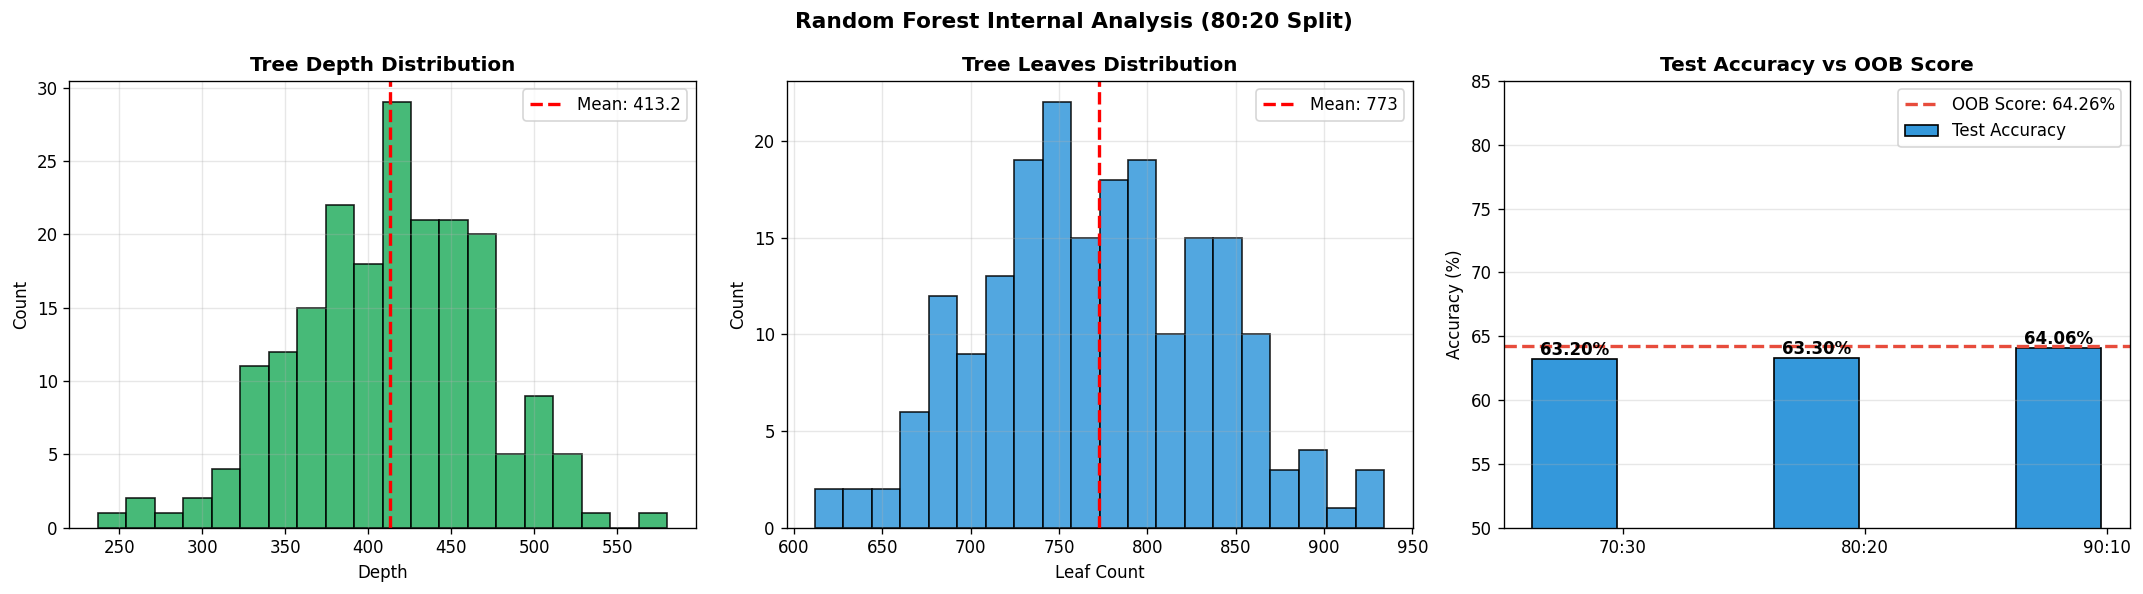


📊 OOB Score: 64.26%
📊 Mean Tree Depth: 413.2
📊 Mean Leaves per Tree: 773
✅ Saved!


In [34]:
# RF specific visualization
# model_80 = all_results['80:20']['model'] # This line will be executed after all_results is populated

# Refit with oob_score=True for OOB analysis
oob_model_params = best_params.copy()
if 'class_weight' in oob_model_params:
    del oob_model_params['class_weight']
oob_params  = {**oob_model_params, 'class_weight': 'balanced', 'oob_score': True, 'random_state': 42, 'n_jobs': 2}

# The next line should retrieve model_80 after all_results is correctly populated
# This entire cell should be re-run after the previous cell successfully completes.

# Assuming all_results is now populated after fixing the previous cell
model_80 = all_results['80:20']['model'] # Re-fetch model_80 here

model_oob  = RandomForestClassifier(**oob_params)
model_oob.fit(all_results['80:20']['Xtr_f'], all_results['80:20']['y_train'])

tree_depths = [t.get_depth() for t in model_oob.estimators_]
n_leaves    = [t.get_n_leaves() for t in model_oob.estimators_]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest Internal Analysis (80:20 Split)', fontsize=13, fontweight='bold')

# Tree depths
axes[0].hist(tree_depths, bins=20, color='#27ae60', edgecolor='black', alpha=0.85)
axes[0].axvline(np.mean(tree_depths), color='red', linestyle='--', lw=2,
                label=f'Mean: {np.mean(tree_depths):.1f}')
axes[0].set_title('Tree Depth Distribution', fontweight='bold')
axes[0].set_xlabel('Depth'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Number of leaves
axes[1].hist(n_leaves, bins=20, color='#3498db', edgecolor='black', alpha=0.85)
axes[1].axvline(np.mean(n_leaves), color='red', linestyle='--', lw=2,
                label=f'Mean: {np.mean(n_leaves):.0f}')
axes[1].set_title('Tree Leaves Distribution', fontweight='bold')
axes[1].set_xlabel('Leaf Count'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

# OOB vs Test accuracy across splits
test_accs = [all_results[s]['accuracy']*100 for s in split_names]
oob_acc   = model_oob.oob_score_ * 100
x_pos     = np.arange(len(split_names))
bars_t    = axes[2].bar(x_pos - 0.2, test_accs, 0.35,
                        label='Test Accuracy', color='#3498db', edgecolor='black')
axes[2].axhline(y=oob_acc, color='#e74c3c', linestyle='--', lw=2,
                label=f'OOB Score: {oob_acc:.2f}%')
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(split_names)
axes[2].set_ylim([50, 85])
for bar, v in zip(bars_t, test_accs):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Test Accuracy vs OOB Score', fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_rf/11_rf_internal_analysis.png', bbox_inches='tight')
plt.show()
print(f'\n📊 OOB Score: {oob_acc:.2f}%')
print(f'📊 Mean Tree Depth: {np.mean(tree_depths):.1f}')
print(f'📊 Mean Leaves per Tree: {np.mean(n_leaves):.0f}')
print('✅ Saved!')

## 📊 Step 17: Final Summary Dashboard

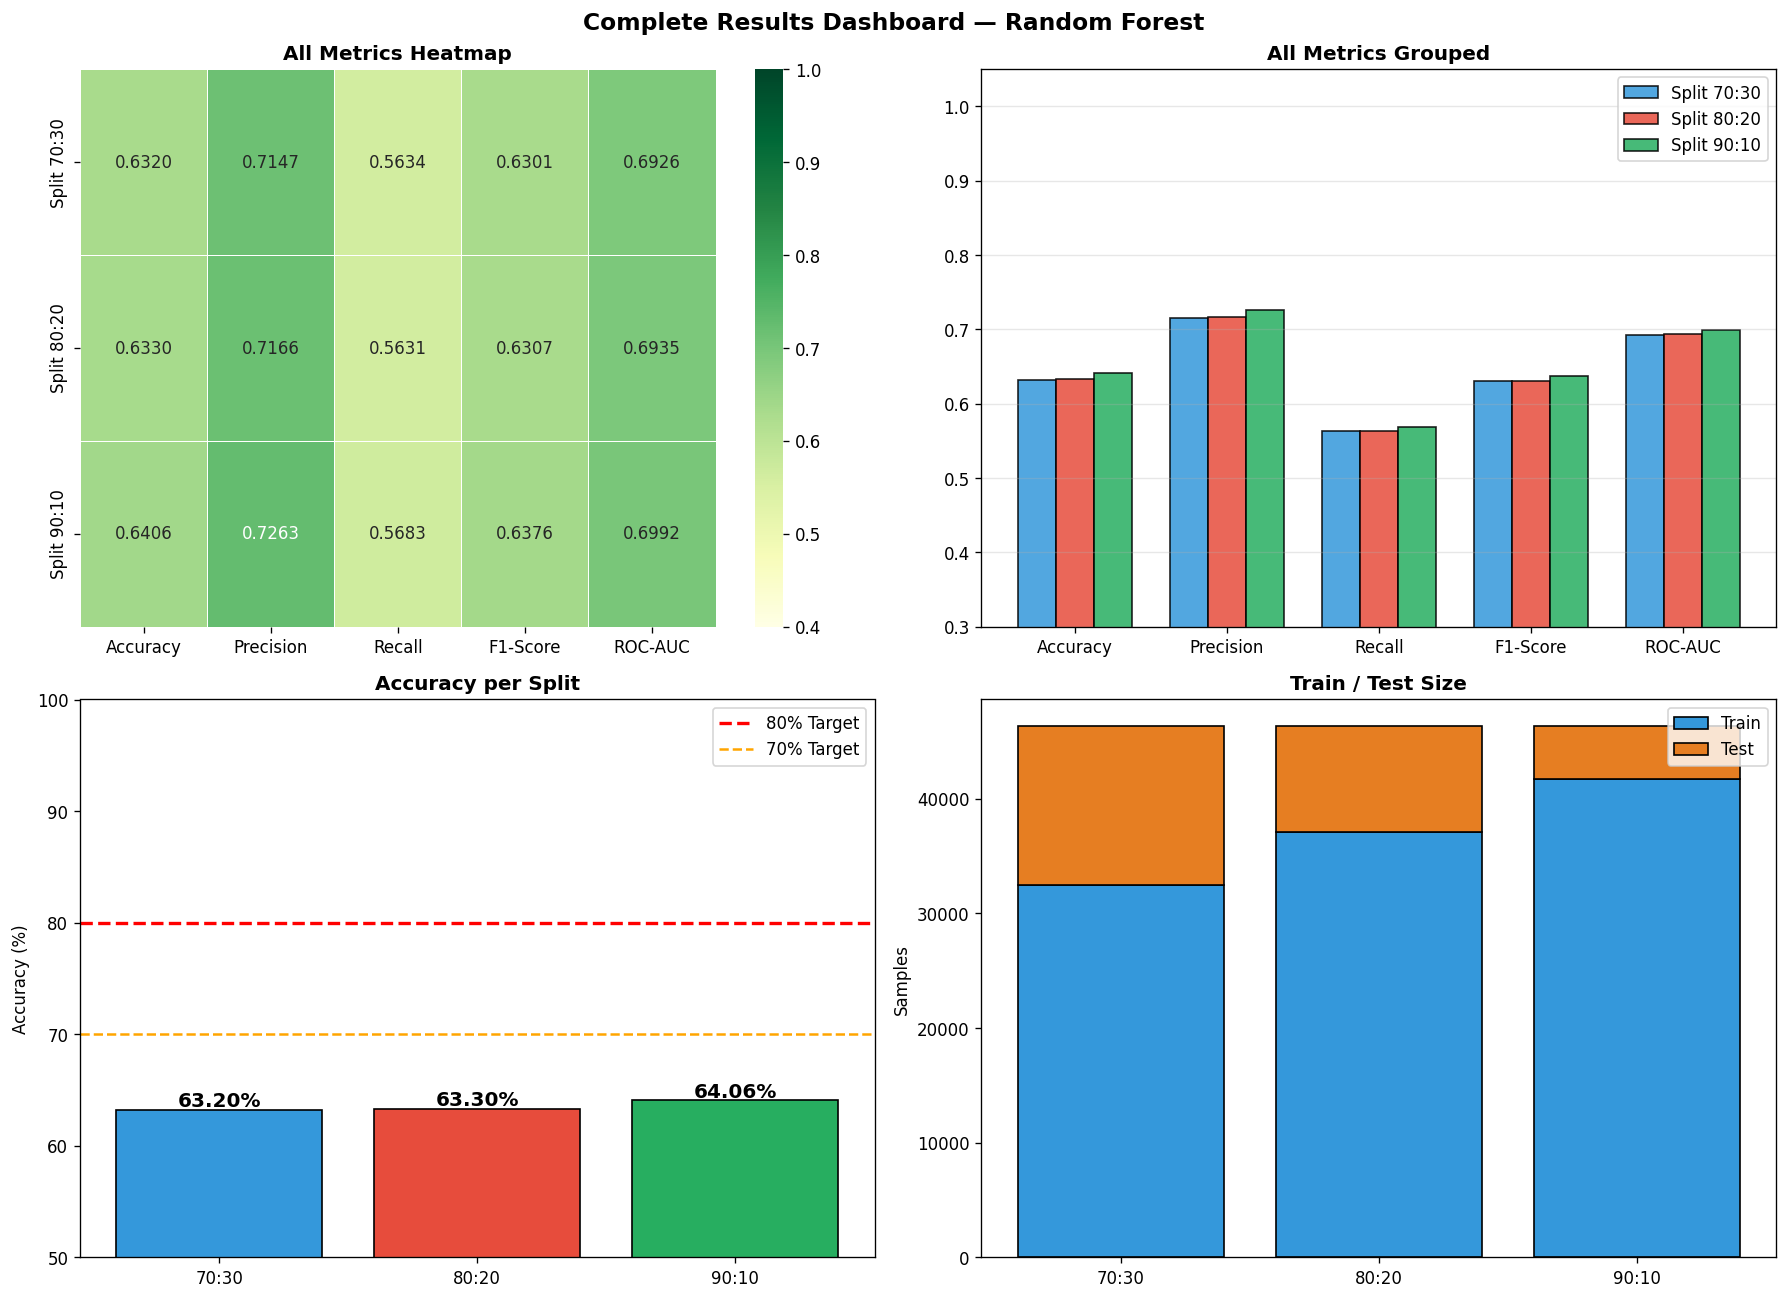

✅ Saved!


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Complete Results Dashboard — Random Forest', fontsize=14, fontweight='bold')

all_mk = ['accuracy','precision','recall','f1','roc_auc']
all_ml = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

# Heatmap
hd  = [[all_results[s][k] for k in all_mk] for s in split_names]
hdf = pd.DataFrame(hd, index=[f'Split {s}' for s in split_names], columns=all_ml)
sns.heatmap(hdf, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0,0],
            linewidths=0.5, vmin=0.4, vmax=1.0)
axes[0,0].set_title('All Metrics Heatmap', fontweight='bold')

# Grouped bar
x2 = np.arange(len(all_mk))
for i, (sname, res) in enumerate(all_results.items()):
    axes[0,1].bar(x2+i*0.25, [res[k] for k in all_mk], 0.25,
                  label=f'Split {sname}', color=colors_roc[i],
                  edgecolor='black', alpha=0.85)
axes[0,1].set_xticks(x2+0.25); axes[0,1].set_xticklabels(all_ml)
axes[0,1].set_ylim([0.3, 1.05])
axes[0,1].set_title('All Metrics Grouped', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.3)

# Accuracy bar
acc_p2 = [all_results[s]['accuracy']*100 for s in split_names]
bars3  = axes[1,0].bar(split_names, acc_p2, color=colors_roc, edgecolor='black')
axes[1,0].axhline(y=80, color='red', linestyle='--', lw=2, label='80% Target')
axes[1,0].axhline(y=70, color='orange', linestyle='--', lw=1.5, label='70% Target')
for bar, v in zip(bars3, acc_p2):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                   f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1,0].set_ylim([50, 100])
axes[1,0].set_title('Accuracy per Split', fontweight='bold')
axes[1,0].set_ylabel('Accuracy (%)'); axes[1,0].legend()

# Train/Test size
tr_s = [all_results[s]['train_size'] for s in split_names]
te_s = [all_results[s]['test_size_n'] for s in split_names]
axes[1,1].bar(split_names, tr_s, label='Train', color='#3498db', edgecolor='black')
axes[1,1].bar(split_names, te_s, bottom=tr_s, label='Test', color='#e67e22', edgecolor='black')
axes[1,1].set_title('Train / Test Size', fontweight='bold')
axes[1,1].set_ylabel('Samples'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('results_rf/12_final_dashboard.png', bbox_inches='tight')
plt.show(); print('✅ Saved!')

## 🏆 Step 18: Final Results Summary Table

In [36]:
summary = []
for sname, res in all_results.items():
    summary.append({
        'Split'     : sname,
        'Train Size': f"{res['train_size']:,}",
        'Test Size' : f"{res['test_size_n']:,}",
        'Accuracy'  : f"{res['accuracy']*100:.2f}%",
        'Precision' : f"{res['precision']:.4f}",
        'Recall'    : f"{res['recall']:.4f}",
        'F1-Score'  : f"{res['f1']:.4f}",
        'ROC-AUC'   : f"{res['roc_auc']:.4f}",
        'PR-AUC'    : f"{res['pr_auc']:.4f}"
    })

sdf = pd.DataFrame(summary)
print('\n' + '='*95)
print('        📊 FINAL RESULTS — RANDOM FOREST | BANGLA SPORTS SENTIMENT')
print('='*95)
print(sdf.to_string(index=False))
print('='*95)
print(f'\n🔧 Best Hyperparameters (tuned on 80:20 via RandomizedSearchCV):')
for k,v in best_params.items(): print(f'   {k}: {v}')
print(f'   Best CV Accuracy: {best_cv_score*100:.2f}%')
print(f'\n📋 Feature Pipeline:')
print(f'   TF-IDF: word ngram(1,2), max_features=12000, sublinear_tf=True')
print(f'   Feature Selection: Chi2 SelectKBest (k=2000)')
print(f'   Model: RandomForestClassifier')
print(f'\n📋 Dataset: Raw=82,611 → After cleanup={len(df_clean):,}')
print(f'\n⚠️  Note: RF text classification এ MNB/SVM এর চেয়ে কম accuracy দেয়')
print(f'          কারণ RF sparse high-dim TF-IDF features এ less effective')
print('\n✅ সব কাজ সম্পন্ন!')
print('\nSaved Plots (results_rf/ folder):')
for f in sorted(os.listdir('results_rf')):
    print(f'   📊 results_rf/{f}')


        📊 FINAL RESULTS — RANDOM FOREST | BANGLA SPORTS SENTIMENT
Split Train Size Test Size Accuracy Precision Recall F1-Score ROC-AUC PR-AUC
70:30     32,427    13,898   63.20%    0.7147 0.5634   0.6301  0.6926 0.7402
80:20     37,060     9,265   63.30%    0.7166 0.5631   0.6307  0.6935 0.7402
90:10     41,692     4,633   64.06%    0.7263 0.5683   0.6376  0.6992 0.7451

🔧 Best Hyperparameters (tuned on 80:20 via RandomizedSearchCV):
   n_estimators: 200
   min_samples_split: 10
   min_samples_leaf: 3
   max_features: sqrt
   max_depth: None
   class_weight: None
   Best CV Accuracy: 64.68%

📋 Feature Pipeline:
   TF-IDF: word ngram(1,2), max_features=12000, sublinear_tf=True
   Feature Selection: Chi2 SelectKBest (k=2000)
   Model: RandomForestClassifier

📋 Dataset: Raw=82,611 → After cleanup=46,325

⚠️  Note: RF text classification এ MNB/SVM এর চেয়ে কম accuracy দেয়
          কারণ RF sparse high-dim TF-IDF features এ less effective

✅ সব কাজ সম্পন্ন!

Saved Plots (results_rf/ fold